# CH 5 - 6 : GENERATING CONFIDENCE INTERVALS WITH THE BOOTSTRAP

## Objectif pédagogique

Ce notebook explique comment générer un **intervalle de confiance Bootstrap** pour une stratégie de trading.

L’idée centrale est simple : au lieu de supposer que les rendements suivent une belle loi normale, on utilise directement les rendements observés du **backtest** pour créer des milliers de futurs possibles.

> **Eurêka :** le Bootstrap ne cherche pas à prouver que la stratégie est bonne. Il cherche à mesurer la **marge d’erreur** autour de la performance observée.

## 1. Le problème à résoudre

Quand tu fais un **backtest**, tu observes une moyenne de rendement.

Par exemple, ta stratégie peut afficher une performance moyenne annualisée de $7\%$.

Mais cette valeur n’est pas la vérité absolue.

C’est seulement une **estimation ponctuelle**.

Elle peut être trop optimiste ou trop pessimiste à cause de l’**erreur d’échantillonnage**.

$$
\text{Performance observée} = \text{Performance réelle} + \text{Erreur d'échantillonnage}
$$

Le rôle de l’**intervalle de confiance** est donc de répondre à cette question :

> Si mon backtest montre $7\%$, dans quelle fourchette raisonnable peut se trouver la vraie performance future ?

## 2. Pourquoi utiliser le Bootstrap ?

Les formules classiques d’intervalle de confiance supposent souvent que les rendements se comportent de manière propre, stable et proche d’une loi normale.

En trading, cette hypothèse est souvent fragile.

Les rendements peuvent avoir :

- des **queues épaisses** ;
- des pertes rares mais violentes ;
- des clusters de volatilité ;
- une distribution asymétrique ;
- des périodes de marché très différentes.

Le **Bootstrap** propose une idée plus empirique :

> Au lieu d’imposer une théorie parfaite aux rendements, on laisse les données historiques parler.

## 3. La méthode des centiles Bootstrap

La méthode des centiles est la version la plus intuitive.

Elle suit cette logique :

1. On part des rendements du **backtest**.
2. On crée un nouvel échantillon en tirant au hasard avec remise.
3. On calcule la moyenne de cet échantillon.
4. On répète l’opération des milliers de fois.
5. On trie toutes les moyennes simulées.
6. On coupe les valeurs extrêmes à gauche et à droite.
7. Ce qui reste donne l’**intervalle de confiance**.

Pour un niveau de confiance donné, le pourcentage à retirer de chaque côté est :

$$
X = \frac{100 - \text{Niveau de Confiance Désiré}}{2}
$$

Exemple pour un **IC à 90\%** :

$$
X = \frac{100 - 90}{2} = 5\%
$$

On retire donc les $5\%$ les plus faibles et les $5\%$ les plus élevés.

## 4. Différence fondamentale avec la p-value

Pour calculer une **p-value**, on teste une hypothèse nulle.

En EBTA, cette hypothèse ressemble souvent à ceci :

$$
H_0 : \mu \leq 0
$$

Dans ce cas, on peut être amené à **zéro-centrer** les rendements pour simuler un monde où la stratégie n’a aucun talent.

Mais pour un **intervalle de confiance Bootstrap**, le but est différent.

On ne cherche pas à créer un monde sans talent.

On cherche à estimer la marge d’erreur autour de la performance observée.

Donc on ne zéro-centre pas.

| Outil | Question posée | Zéro-centrage ? |
|---|---|---|
| **p-value Bootstrap** | Le résultat est-il trop rare sous $H_0$ ? | Oui, souvent |
| **IC Bootstrap** | Où peut se situer la vraie performance ? | Non |

> **Eurêka :** la p-value teste si le talent existe ; l’intervalle de confiance mesure la zone probable où ce talent se situe.

## 5. Création d’un faux backtest de trading

Nous allons simuler une série de rendements journaliers.

L’objectif n’est pas de créer une stratégie parfaite, mais d’avoir un exemple concret pour comprendre la mécanique.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pour rendre les résultats reproductibles
rng = np.random.default_rng(42)

# Paramètres d'un faux backtest
n_days = 500
daily_edge = 0.00025
daily_volatility = 0.01

# Rendements journaliers simulés
returns = rng.normal(loc=daily_edge, scale=daily_volatility, size=n_days)

# Ajout de quelques chocs négatifs pour imiter les queues épaisses du trading
shock_indices = rng.choice(n_days, size=8, replace=False)
returns[shock_indices] += rng.normal(loc=-0.035, scale=0.015, size=8)

returns_series = pd.Series(returns, name="daily_return")

summary = pd.DataFrame({
    "Métrique": [
        "Nombre de jours",
        "Moyenne journalière",
        "Volatilité journalière",
        "Moyenne annualisée approximative",
        "Volatilité annualisée approximative"
    ],
    "Valeur": [
        len(returns_series),
        returns_series.mean(),
        returns_series.std(ddof=1),
        returns_series.mean() * 252,
        returns_series.std(ddof=1) * np.sqrt(252)
    ]
})

summary

,Métrique,Valeur
0,Nombre de jours,500.000000
1,Moyenne journalière,-0.000465
2,Volatilité journalière,0.010707
3,Moyenne annualisée approximative,-0.117276
4,Volatilité annualisée approximative,0.169974


## 6. Visualiser les rendements du backtest

Avant de calculer un intervalle de confiance, il faut toujours regarder les données.

Une moyenne seule peut cacher une distribution très irrégulière.

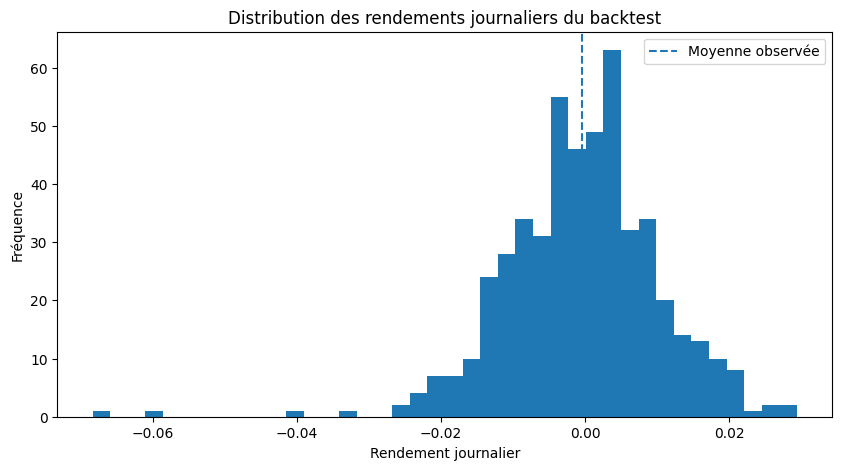

In [2]:
plt.figure(figsize=(10, 5))
plt.hist(returns_series, bins=40)
plt.title("Distribution des rendements journaliers du backtest")
plt.xlabel("Rendement journalier")
plt.ylabel("Fréquence")
plt.axvline(returns_series.mean(), linestyle="--", label="Moyenne observée")
plt.legend()
plt.show()

## 7. Fonction Bootstrap pour intervalle de confiance

La fonction ci-dessous applique la **méthode des centiles Bootstrap**.

Elle prend les rendements observés, crée $B$ échantillons avec remise, calcule $B$ moyennes, puis récupère les percentiles correspondant au niveau de confiance demandé.

In [8]:
def bootstrap_confidence_interval(data, confidence_level=0.90, n_bootstrap=5000, seed=123):
    """
    Calcule un intervalle de confiance Bootstrap par la méthode des centiles.
    """
    data = np.asarray(data)
    rng = np.random.default_rng(seed)
    n = len(data)

    bootstrap_means = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = rng.choice(data, size=n, replace=True)
        bootstrap_means[i] = sample.mean()

    alpha = 1 - confidence_level
    lower_percentile = 100 * (alpha / 2)
    upper_percentile = 100 * (1 - alpha / 2)

    lower_bound = np.percentile(bootstrap_means, lower_percentile)
    upper_bound = np.percentile(bootstrap_means, upper_percentile)

    return lower_bound, upper_bound, bootstrap_means

## 8. Calcul d’un IC Bootstrap à 90\%

Nous allons maintenant appliquer exactement la logique décrite dans le cours.

Avec $5\,000$ simulations et un niveau de confiance de $90\%$, on retire $5\%$ des valeurs extrêmes de chaque côté.

In [4]:
confidence_level = 0.90
n_bootstrap = 5000

lower, upper, bootstrap_means = bootstrap_confidence_interval(
    returns_series,
    confidence_level=confidence_level,
    n_bootstrap=n_bootstrap,
    seed=7
)

result_90 = pd.DataFrame({
    "Élément": [
        "Moyenne observée journalière",
        "Borne inférieure IC 90%",
        "Borne supérieure IC 90%",
        "Moyenne observée annualisée",
        "Borne inférieure annualisée IC 90%",
        "Borne supérieure annualisée IC 90%"
    ],
    "Valeur": [
        returns_series.mean(),
        lower,
        upper,
        returns_series.mean() * 252,
        lower * 252,
        upper * 252
    ]
})

result_90

,Élément,Valeur
0,Moyenne observée journalière,-0.000465
1,Borne inférieure IC 90%,-0.001283
2,Borne supérieure IC 90%,0.000324
3,Moyenne observée annualisée,-0.117276
4,Borne inférieure annualisée IC 90%,-0.323255
5,Borne supérieure annualisée IC 90%,0.081590


## 9. Visualisation de la distribution Bootstrap

La distribution ci-dessous n’est pas la distribution des rendements journaliers.

C’est la distribution des **moyennes simulées**.

C’est très important.

Elle répond à cette question :

> Si mon backtest était répété sous des variations plausibles du même passé, quelles moyennes pourrais-je obtenir ?

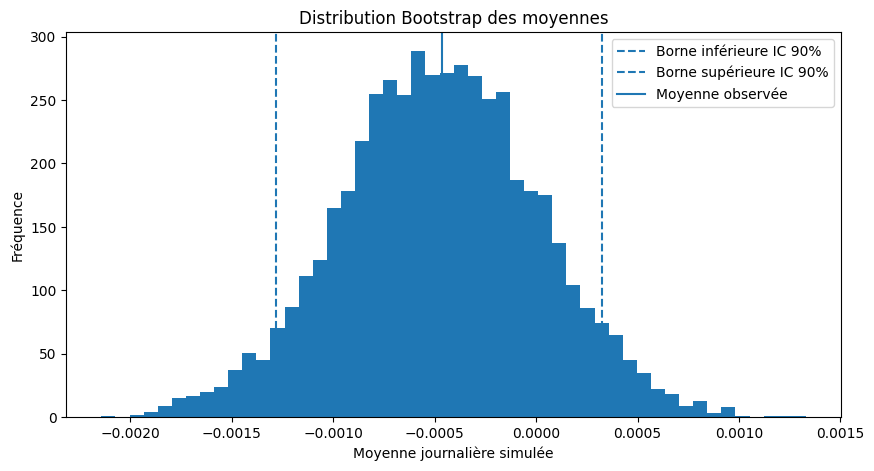

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=50)
plt.axvline(lower, linestyle="--", label="Borne inférieure IC 90%")
plt.axvline(upper, linestyle="--", label="Borne supérieure IC 90%")
plt.axvline(returns_series.mean(), linestyle="-", label="Moyenne observée")
plt.title("Distribution Bootstrap des moyennes")
plt.xlabel("Moyenne journalière simulée")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 10. Comparer IC 90\%, 95\% et 99\%

Plus on demande de confiance, plus l’intervalle devient large.

C’est une loi fondamentale.

Tu gagnes en sécurité statistique, mais tu perds en précision.

$$
\text{Plus de confiance} = \text{Intervalle plus large}
$$

In [6]:
confidence_levels = [0.90, 0.95, 0.99]
rows = []

for cl in confidence_levels:
    low, high, _ = bootstrap_confidence_interval(
        returns_series,
        confidence_level=cl,
        n_bootstrap=5000,
        seed=7
    )
    rows.append({
        "Niveau de confiance": f"{int(cl * 100)}%",
        "Borne inférieure journalière": low,
        "Borne supérieure journalière": high,
        "Largeur journalière": high - low,
        "Borne inférieure annualisée": low * 252,
        "Borne supérieure annualisée": high * 252,
        "Largeur annualisée": (high - low) * 252
    })

ci_comparison = pd.DataFrame(rows)
ci_comparison

,Niveau de confiance,Borne inférieure journalière,Borne supérieure journalière,Largeur journalière,Borne inférieure annualisée,Borne supérieure annualisée,Largeur annualisée
0,90%,-0.001283,0.000324,0.001607,-0.323255,0.081590,0.404845
1,95%,-0.001459,0.000473,0.001932,-0.367694,0.119253,0.486947
2,99%,-0.001739,0.000786,0.002525,-0.438270,0.198021,0.636291


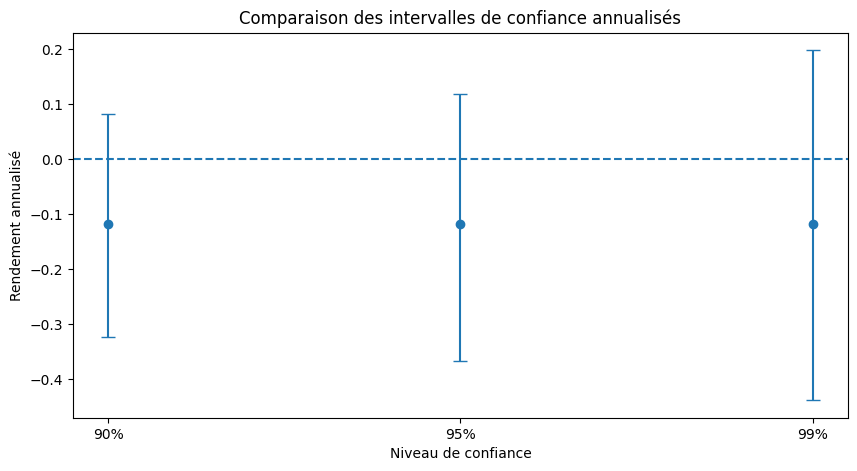

In [7]:
plt.figure(figsize=(10, 5))

x_positions = np.arange(len(ci_comparison))
lower_values = ci_comparison["Borne inférieure annualisée"].values
upper_values = ci_comparison["Borne supérieure annualisée"].values
means = np.repeat(returns_series.mean() * 252, len(ci_comparison))

plt.errorbar(
    x_positions,
    means,
    yerr=[means - lower_values, upper_values - means],
    fmt="o",
    capsize=5
)

plt.xticks(x_positions, ci_comparison["Niveau de confiance"])
plt.axhline(0, linestyle="--")
plt.title("Comparaison des intervalles de confiance annualisés")
plt.xlabel("Niveau de confiance")
plt.ylabel("Rendement annualisé")
plt.show()

## 11. Interprétation trading EBTA

Imaginons que le résultat annualisé observé soit positif.

Deux scénarios sont possibles.

### Cas favorable

Si l’intervalle de confiance est entièrement au-dessus de zéro :

$$
IC = [2\% ; 12\%]
$$

Alors même la borne basse reste positive.

Cela suggère que la stratégie possède une marge de sécurité statistique.

### Cas fragile

Si l’intervalle de confiance traverse zéro :

$$
IC = [-3\% ; 13\%]
$$

Alors la stratégie peut être rentable, mais l’incertitude est encore trop grande.

Le backtest n’est pas forcément mauvais, mais il n’est pas encore assez solide.

> **Eurêka :** ce n’est pas la moyenne du backtest qui te protège. C’est la borne basse de ton intervalle de confiance.

## 12. Pourquoi Monte Carlo Permutation ne donne pas un IC ?

La **permutation de Monte Carlo** casse volontairement le lien entre le signal et le marché.

Elle sert à créer un monde où le signal n’a plus de pouvoir prédictif.

C’est parfait pour tester la chance.

Mais ce n’est pas adapté pour estimer la vraie moyenne future de la stratégie.

| Méthode | But principal | Peut générer un IC de performance ? |
|---|---|---|
| **Bootstrap** | Estimer l’incertitude autour d’un paramètre | Oui |
| **Monte Carlo Permutation** | Tester si le lien signal-marché est dû au hasard | Non |

La raison est simple : un IC cherche à approximer un **paramètre de population**, comme le rendement moyen futur.

La permutation, elle, détruit justement la structure qui permet d’estimer ce paramètre.

## 13. Check-list opérationnelle EBTA

Avant d’utiliser un IC Bootstrap dans ton processus de validation, vérifie les points suivants :

| Point de contrôle | Question à poser | Pourquoi c’est important |
|---|---|---|
| **Nombre d’itérations** | Ai-je utilisé environ $5\,000$ simulations ou plus ? | Stabiliser les bornes |
| **Taille d’échantillon** | Chaque tirage a-t-il la même taille que le backtest ? | Respecter la structure du test |
| **Avec remise** | Les observations peuvent-elles être tirées plusieurs fois ? | C’est le principe du Bootstrap |
| **Pas de zéro-centrage** | Ai-je gardé la moyenne observée ? | Un IC estime la performance réelle |
| **Lecture de la borne basse** | La borne inférieure est-elle acceptable ? | Mesurer la marge de sécurité |
| **Niveau de confiance** | Ai-je compris que $99\%$ sera plus large que $90\%$ ? | Éviter une fausse précision |

## 14. Mini-exercice

Supposons qu’une stratégie ait une moyenne annualisée observée de $9\%$.

Après Bootstrap, on obtient :

$$
IC_{90\%} = [1\% ; 17\%]
$$

Puis :

$$
IC_{99\%} = [-5\% ; 23\%]
$$

### Question

La stratégie est-elle clairement robuste ?

### Réponse guidée

À $90\%$, la borne basse est positive.

C’est encourageant.

Mais à $99\%$, la borne basse passe sous zéro.

Cela signifie que sous un niveau d’exigence plus strict, l’incertitude reste importante.

> **Conclusion EBTA :** la stratégie est prometteuse, mais pas encore blindée. Il faut regarder la taille de l’échantillon, la stabilité par période, le data mining et la logique économique du signal.

## 15. Synthèse finale

L’**intervalle de confiance Bootstrap** est l’un des outils les plus utiles pour un trader quantitatif.

Il transforme une performance unique en une fourchette réaliste.

Il empêche de croire naïvement que la moyenne du backtest est une vérité fixe.

Il force le trader à penser en termes d’incertitude, de marge d’erreur et de robustesse.

> **L’Eurêka final :** un backtest ne te donne pas une vérité. Il te donne une estimation. Le Bootstrap te montre jusqu’où cette estimation peut raisonnablement se tromper.

## Annexe — Source originale collée

### **CH 5 - 6 : GENERATING CONFIDENCE INTERVALS WITH THE BOOTSTRAP**

Voici l’analyse technique de la génération des intervalles de confiance (IC) par la méthode Bootstrap, une alternative informatique puissante aux formules classiques pour quantifier l'incertitude d'une stratégie de trading.

#### **Idées clés :**
*   **Méthode des centiles :** La procédure privilégiée par Aronson est la "méthode des centiles bootstrap", réputée pour sa simplicité et son efficacité.
*   **Inapplicabilité de Monte Carlo :** Contrairement au Bootstrap, la méthode de permutation de Monte Carlo ne peut pas être utilisée pour générer des IC car elle ne teste pas de paramètre de population comme le rendement moyen.
*   **Élagage statistique :** L'IC est formé en triant des milliers de moyennes simulées et en retirant un pourcentage déterminé de valeurs extrêmes aux deux extrémités.
*   **Convergence :** La validité de l'intervalle repose sur le "Bootstrap Theorem", assurant que la distribution simulée converge vers la vérité à mesure que l'échantillon grandit.

#### **Référence :**
*Generating Confidence Intervals with the Bootstrap*, pages 248 à 250.

#### **Citation Directe :**
« The bootstrap percentile method, is popular, easy to use, and generally gives good results. » (Page 248).

#### **Vision Macro :**
L'enjeu est de s'affranchir de l'hypothèse (souvent fausse en trading) que les rendements suivent une loi normale (courbe en cloche parfaite). En utilisant le Bootstrap pour créer des intervalles de confiance, le trader laisse les données "parler d'elles-mêmes". Cela permet d'obtenir une fourchette de performance future beaucoup plus réaliste, reflétant les particularités (pics, queues épaisses) du comportement historique de la règle.

#### **Vision Micro :**
La procédure technique (méthode des centiles) suit ces étapes rigoureuses :
1.  **Rééchantillonnage :** On effectue 5 000 tirages avec remise à partir de l'échantillon original (contrairement au test de p-value, on ne procède **pas** au zéro-centrage ici, car on veut centrer la distribution sur le profit réel).
2.  **Calcul des moyennes :** On calcule la moyenne pour chacune des 5 000 simulations.
3.  **Tri par rang :** L'ordinateur classe ces 5 000 valeurs de la plus élevée à la plus basse.
4.  **Détermination du seuil d'élagage ($X$) :** On utilise la formule :
    $$X = \frac{100 - \text{Niveau de Confiance Désiré}}{2}$$
5.  **Élimination des extrêmes :** 
    *   *Exemple pour un IC à 90 % :* On retire les 5 % les plus hauts (250 valeurs) et les 5 % les plus bas (250 valeurs).
6.  **Fixation des bornes :** La valeur la plus haute restante devient la borne supérieure, et la plus basse restante devient la borne inférieure.

#### **Résumé Simplifié :**
Pour trouver la marge d'erreur de ton profit, on crée 5 000 versions imaginaires de ton passé en mélangeant tes jours de trading. On range les 5 000 résultats du meilleur au pire. Si tu veux être sûr à 90 %, on jette les 250 meilleurs et les 250 pires. Ce qui reste au milieu est ton intervalle de confiance : c'est là où ton talent se situe probablement.

#### **Exemples du livre pour mieux comprendre :**
*   **L'IC à 90 % :** Sur 5 000 moyennes triées, Aronson explique qu'il faut supprimer les 250 valeurs de chaque côté. Si la valeur la plus haute après élagage est 12 % et la plus basse est 2 %, alors l'IC est [2 % ; 12 %].
*   **L'IC à 99 % :** Pour être plus "certain", on n'élimine que les 25 valeurs les plus extrêmes (0,5 %) de chaque côté. L'intervalle résultant est mécaniquement beaucoup plus large, perdant en précision ce qu'il gagne en confiance.

#### **Actions Concrètes :**
*   **Utilisez 5 000 itérations :** C'est le nombre nécessaire pour que les bornes de l'intervalle soient stables d'un calcul à l'autre.
*   **Ne cherchez pas d'IC avec Monte Carlo :** Si votre logiciel propose un intervalle de confiance via une permutation de Monte Carlo, c'est une erreur conceptuelle selon EBTA.
*   **Appliquez le tri par rang :** Assurez-vous que votre algorithme classe bien l'intégralité des moyennes simulées avant d'appliquer les coupures de centiles.
*   **Vérifiez la taille $N$ :** Chaque simulation bootstrap doit comporter exactement le même nombre de jours que votre backtest initial.

#### **À retenir absolument :**
*   L'IC Bootstrap utilise la **méthode des centiles**.
*   Il nécessite **5 000 simulations** pour être statistiquement fiable.
*   Il ne nécessite **pas de zéro-centrage** (contrairement à la p-value).
*   **Plus de confiance = Moins de précision** (intervalle plus large).
*   C'est l'outil qui définit la **marge d'erreur** de votre espérance de gain.

J'ai terminé l'analyse de la génération des intervalles de confiance avec le Bootstrap selon le protocole EBTA.